# Set 12 - Zeitlicher Split, Lag-Merkmale und Backtesting

**Lernziele:** Prognosezeitpunkt festlegen, Merkmale nur aus bekannter Vergangenheit bilden, Zeitreihen-Folds darstellen und Modelle gegen einfache Baselines testen.

**Aufgabe:** Vor Beginn der nächsten Stunde y[t] schätzen. Zu diesem Zeitpunkt ist die Sensorhistorie bis t-1 bekannt. Im späteren Test kommen Messwerte stündlich neu hinzu; das Modell wird dabei nicht neu trainiert. Dies ist eine **rollende Ein-Schritt-Prognose**, kein 168-Stunden-Forecast von einem einzigen Ursprung.

Das entspricht der chronologischen Trennung auf Seite 24 der Kurs-PDF.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

kandidaten = [Path.cwd(), *Path.cwd().parents]
set_ordner = next((p for basis in kandidaten
                   for p in (basis, basis / "set12-zeitreihenanalyse")
                   if (p / "zeitreihen_tools.py").exists()), None)
if set_ordner is None:
    raise FileNotFoundError("Notebook bitte innerhalb des Kursordners starten.")
if str(set_ordner) not in sys.path:
    sys.path.insert(0, str(set_ordner))
from zeitreihen_tools import (FARBEN, plot_stil, zeitachse, synthetische_reihe,
                              lag_tabelle, metriken, lade_bike, lade_energie)
plot_stil()

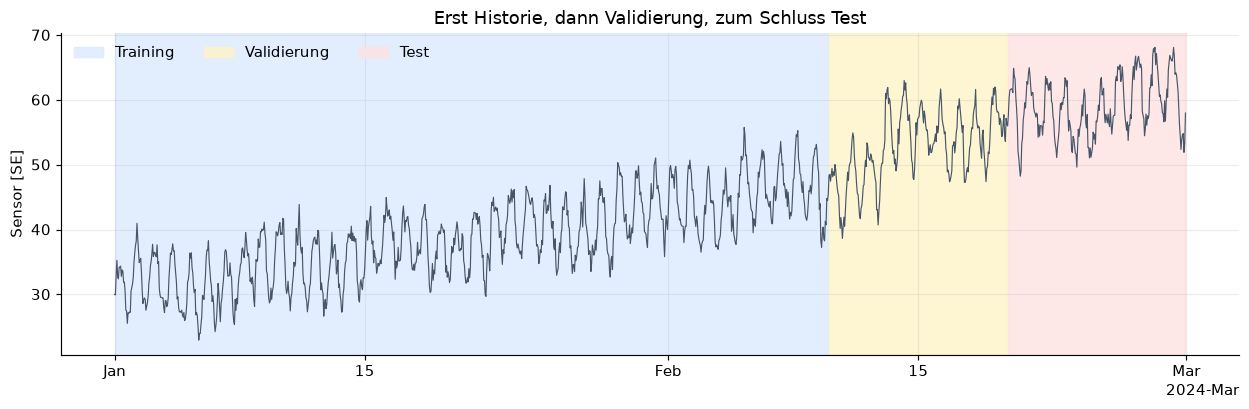

In [2]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

y = synthetische_reihe(n=1440).wert
train_ende = y.index[959]
val_ende = y.index[1199]
train_roh = y.loc[:train_ende]
val_roh = y.loc[train_ende + pd.Timedelta(hours=1):val_ende]
test_roh = y.loc[val_ende + pd.Timedelta(hours=1):]
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y, color=FARBEN["roh"], lw=0.8)
for serie, name, farbe in [(train_roh,"Training",FARBEN["train"]), (val_roh,"Validierung",FARBEN["val"]), (test_roh,"Test",FARBEN["test"])]:
    ax.axvspan(serie.index[0], serie.index[-1], color=farbe, alpha=0.8, label=name)
ax.set(title="Erst Historie, dann Validierung, zum Schluss Test", ylabel="Sensor [SE]")
zeitachse(ax); ax.legend(ncol=3); plt.tight_layout(); plt.show()

## 1. Aus einer Zeitreihe wird eine überwachte Tabelle

Die Zielspalte ist y[t]. `lag_1` bedeutet y[t-1], `lag_24` dieselbe Stunde des Vortags. Ein rollendes Merkmal zur Vorhersage von y[t] muss mit `shift(1)` beginnen. Kalendermerkmale für t sind schon vorher bekannt.

Die ursprünglichen Zeitgrenzen werden vor EDA festgelegt. Die deterministische Feature-Erzeugung darf die ganze Reihe durchlaufen, **weil jede Zeile nur zurückschaut** und keinerlei Statistik über die gesamte Tabelle fitten muss. Anfangs fehlen Lags; diese Zeilen fallen weg.

In [3]:
X, ziel = lag_tabelle(y)
X_train, y_train = X.loc[:train_ende], ziel.loc[:train_ende]
X_val = X.loc[train_ende + pd.Timedelta(hours=1):val_ende]
y_val = ziel.loc[X_val.index]
X_test = X.loc[val_ende + pd.Timedelta(hours=1):]
y_test = ziel.loc[X_test.index]
display(X_train.head(3).round(3))
zeitpunkt = X_train.index[10]
print("Zielzeit:", zeitpunkt)
print("lag_1:", X.loc[zeitpunkt,"lag_1"], "= letzter bekannter Wert:", y.loc[zeitpunkt-pd.Timedelta(hours=1)])
print("24h-Mittel:", X.loc[zeitpunkt,"mittel_24"])
assert np.isclose(X.loc[zeitpunkt,"mittel_24"], y.loc[zeitpunkt-pd.Timedelta(hours=24):zeitpunkt-pd.Timedelta(hours=1)].mean())

,lag_1,lag_2,lag_24,lag_168,mittel_24,std_24,mittel_168,std_168,stunde_sin,stunde_cos,wochentag_sin,wochentag_cos,tag_im_jahr_sin,tag_im_jahr_cos
zeit,,,,,,,,,,,,,,
2024-01-08 00:00:00,32.690,31.274,29.308,30.000,31.548,3.292,31.324,3.815,0.000,1.000,0.0,1.0,0.137,0.991
2024-01-08 01:00:00,33.384,32.690,30.860,29.931,31.717,3.276,31.344,3.817,0.259,0.966,0.0,1.0,0.137,0.991
2024-01-08 02:00:00,34.552,33.384,31.965,32.935,31.871,3.321,31.372,3.824,0.500,0.866,0.0,1.0,0.137,0.991


Zielzeit: 2024-01-08 10:00:00
lag_1: 38.41284929361079 = letzter bekannter Wert: 38.41284929361079
24h-Mittel: 32.69710634508639


## 2. Warum `rolling` ohne Verschieben ein Leak ist

Ein falsch gebautes Merkmal kann die Zielvariable bereits enthalten. Wir vergleichen einen kausalen Mittelwert mit einem zentrierten Fenster. Der rote Mittelwert enthält Werte am Zielzeitpunkt und danach und ist deshalb bei unserer Prognoseaufgabe nicht verfügbar.

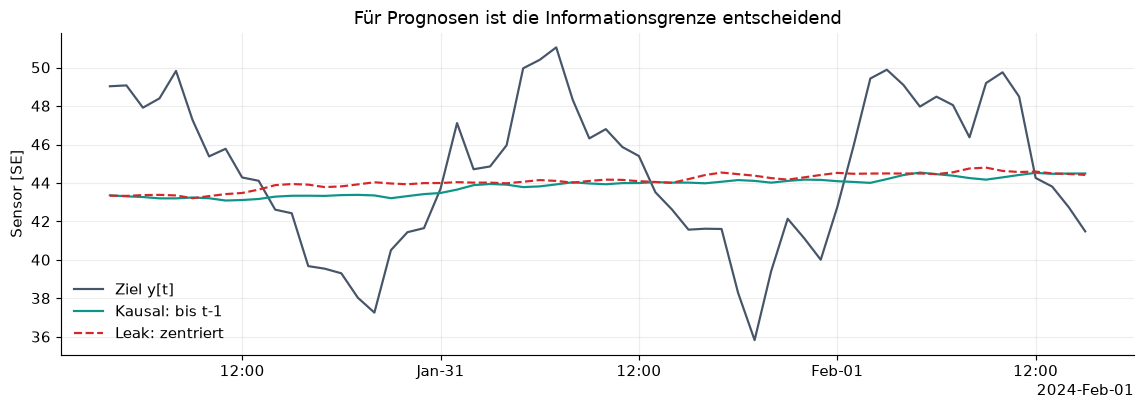

In [4]:
ausschnitt = y.iloc[700:760]
gut = y.shift(1).rolling(24).mean()
falsch = y.rolling(24, center=True).mean()
fig, ax = plt.subplots()
ax.plot(ausschnitt, color=FARBEN["roh"], label="Ziel y[t]")
ax.plot(gut.loc[ausschnitt.index], color=FARBEN["saison"], label="Kausal: bis t-1")
ax.plot(falsch.loc[ausschnitt.index], color="tab:red", ls="--", label="Leak: zentriert")
ax.set(title="Für Prognosen ist die Informationsgrenze entscheidend", ylabel="Sensor [SE]")
zeitachse(ax); ax.legend(); plt.tight_layout(); plt.show()

## 3. Expanding Window und Sliding Window sichtbar machen

`TimeSeriesSplit` trainiert auf älteren und prüft auf späteren Daten. Ein Expanding Window wächst, ein Sliding Window begrenzt die Historie mit `max_train_size`. Hier lassen wir eine Stunde Abstand (`gap=1`) als sichtbare Lücke. Bei anderen Prognosehorizonten oder überlappenden Zielintervallen muss die Lücke anhand der Aufgabe gewählt werden.

Gleiche Zeitabstände sind wichtig: Eine Anzahl von 72 Samples entspricht nur auf einem regelmäßigen Stundenraster 72 Stunden.

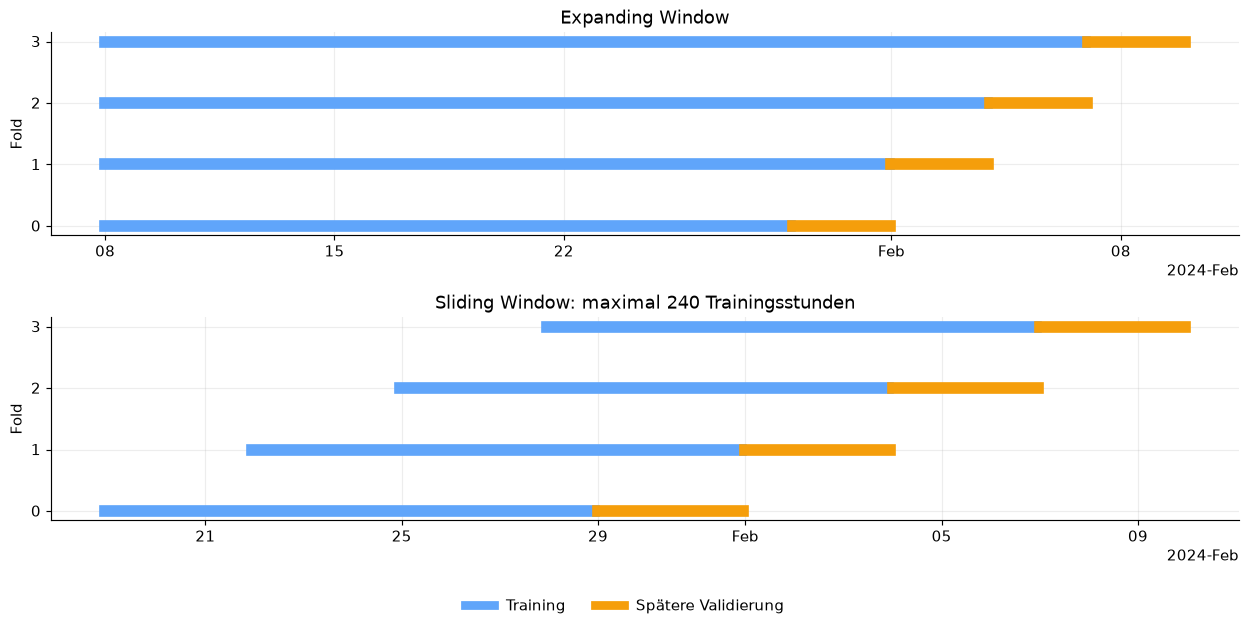

In [5]:
cv = TimeSeriesSplit(n_splits=4, test_size=72, gap=1)
cv_gleitend = TimeSeriesSplit(n_splits=4, test_size=72, gap=1, max_train_size=240)
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
for ax, splitter, titel in [(axes[0],cv,"Expanding Window"), (axes[1],cv_gleitend,"Sliding Window: maximal 240 Trainingsstunden")]:
    for k, (tr, va) in enumerate(splitter.split(X_train)):
        ax.plot(X_train.index[tr], np.full(len(tr),k), lw=8, color="#60a5fa")
        ax.plot(X_train.index[va], np.full(len(va),k), lw=8, color="#f59e0b")
    ax.set(title=titel, ylabel="Fold", yticks=range(4))
    zeitachse(ax)
from matplotlib.lines import Line2D
fig.legend(handles=[Line2D([0],[0],color="#60a5fa",lw=6,label="Training"),
                    Line2D([0],[0],color="#f59e0b",lw=6,label="Spätere Validierung")],
           loc="lower center",ncol=2)
plt.tight_layout(rect=[0,0.07,1,1]); plt.show()

## 4. Hyperparameter nur mit der Trainingshistorie auswählen

Die Pipeline fittet `StandardScaler` innerhalb jedes Folds. Der äußere Validierungsblock zeigt anschließend, wie das gewählte Modell auf dem nächstspäteren Zeitraum funktioniert. Der finale Test bleibt bis zur letzten Bewertung unberührt.

Baseline 1 übernimmt den letzten Wert; Baseline 2 dieselbe Stunde des Vortags. Ein komplexeres Modell muss diese einfachen Vorhersagen erst übertreffen.

In [6]:
pipeline = make_pipeline(StandardScaler(), Ridge())
suche = GridSearchCV(pipeline, {"ridge__alpha":[0.1,1,10,100]}, cv=cv,
                     scoring="neg_mean_absolute_error", n_jobs=1)
suche.fit(X_train,y_train)
print("Gewählt:", suche.best_params_, "CV-MAE:", -suche.best_score_)
val_prognosen = {"Letzter Wert":X_val.lag_1, "Vortag":X_val.lag_24,
                 "Ridge":suche.predict(X_val)}
display(metriken(y_val,val_prognosen).round(3))

Gewählt: {'ridge__alpha': 10} CV-MAE: 1.1405272672822384


,MAE,RMSE
Modell,,
Letzter Wert,1.416,1.768
Vortag,2.844,3.637
Ridge,1.722,2.150


## 5. Einmalige finale Bewertung

Nach Auswahl der Einstellungen fitten wir das Modell auf Training plus Validierung und bewerten den späteren Test. Bei jeder Teststunde dürfen vorherige Testmesswerte als Lags bekannt sein; wir behaupten deshalb keine Prognose des gesamten Testblocks aus einem einzigen Ursprung. Das Modell selbst bleibt während dieses Tests fest.

,MAE,RMSE
Modell,,
Letzter Wert,1.519,1.907
Vortag,2.511,3.114
Ridge,1.236,1.557


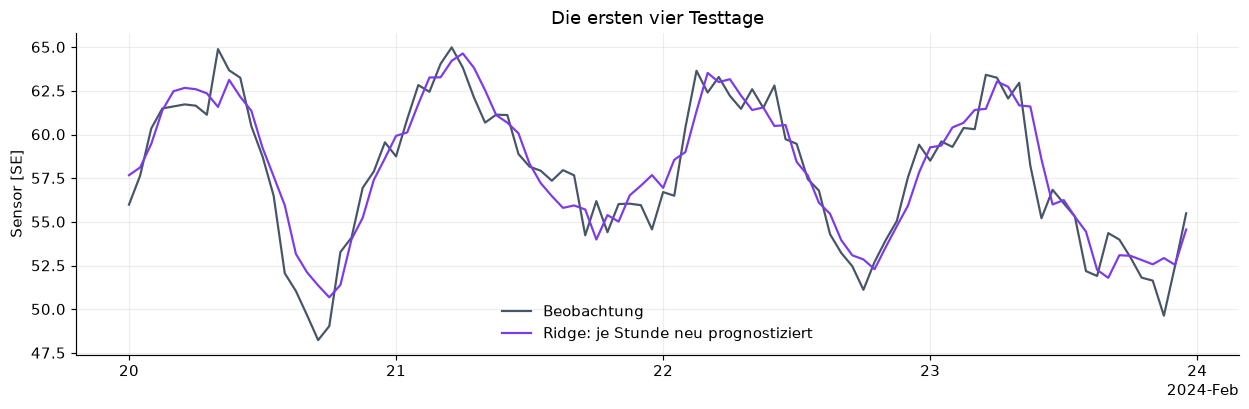

In [7]:
from sklearn.base import clone
final = clone(suche.best_estimator_).fit(pd.concat([X_train,X_val]), pd.concat([y_train,y_val]))
prognosen = {"Letzter Wert":X_test.lag_1, "Vortag":X_test.lag_24, "Ridge":final.predict(X_test)}
display(metriken(y_test,prognosen).round(3))
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(y_test.iloc[:96], color=FARBEN["roh"], label="Beobachtung")
ax.plot(y_test.index[:96], prognosen["Ridge"][:96], color=FARBEN["prognose"], label="Ridge: je Stunde neu prognostiziert")
ax.set(title="Die ersten vier Testtage", ylabel="Sensor [SE]")
zeitachse(ax); ax.legend(); plt.tight_layout(); plt.show()

## Kleine Aufgaben
1. Zeichne einen Fold mit `gap=24` und begründe, ob die Lücke für unsere Ein-Schritt-Aufgabe nötig ist.
2. Vergleiche Expanding Window und Sliding Window nach einem Niveauwechsel.
3. Was müsste sich an Features und Evaluation ändern, wenn der gesamte nächste Tag vorab prognostiziert werden soll?
4. Warum gehören Skalierung und Modell in eine gemeinsame Pipeline?